In [42]:
import numpy as np 
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [28]:
# For reproducibility
np.random.seed(42)

In [ ]:
df = pd.read_csv("../data/raw/Diabetes_and_LifeStyle_Dataset_.csv")

In [30]:
# Basic dataset inspection
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

print("\nSummary statistics:")
display(df.describe())

Dataset Shape: (97297, 31)

First 5 rows:


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1



Summary statistics:


,Age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,...,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000,97297.000000
mean,50.192699,2.004543,118.942886,5.995214,6.997708,5.997031,0.219657,0.250912,0.079067,25.615093,...,185.984234,54.043537,103.000308,121.466407,111.121792,160.014348,9.063591,6.520338,30.222027,0.600039
std,15.492557,1.418060,84.441920,1.780096,1.093726,2.469805,0.414017,0.433540,0.269845,3.588387,...,32.013395,10.275047,33.390145,43.393422,13.590382,30.938915,4.956342,0.813710,9.065063,0.489892
min,19.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,38.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,51.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [31]:
# Missing value analysis
print("\nMissing values per column:")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_data = pd.concat([missing_values, missing_percent], axis=1)
missing_data.columns = ['Missing Values', 'Percentage']
display(missing_data[missing_data['Missing Values'] > 0].sort_values('Missing Values', ascending=False))


Missing values per column:


,Missing Values,Percentage


In [43]:
# No missing values present

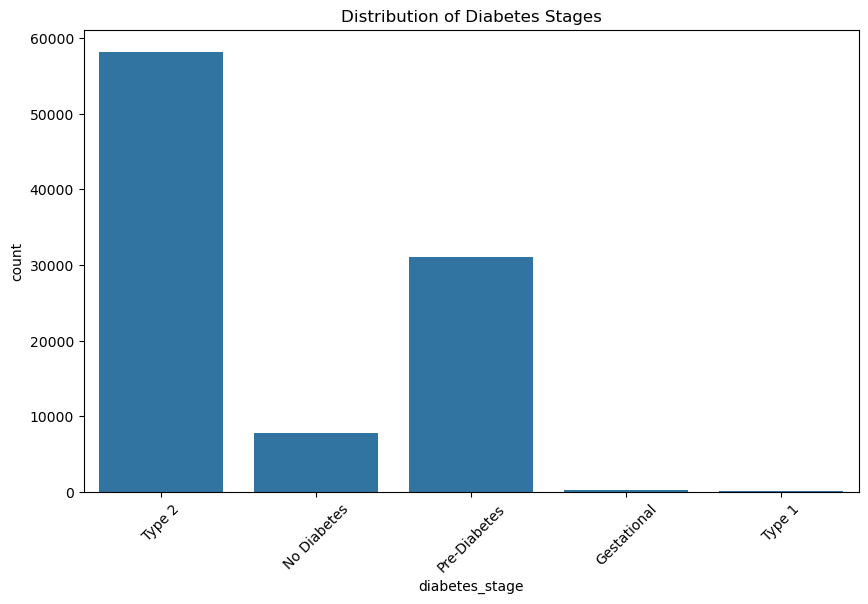


Distribution of Diabetes Stages:


diabetes_stage
Type 2          59.78
Pre-Diabetes    31.87
No Diabetes      7.95
Gestational      0.27
Type 1           0.12
Name: proportion, dtype: float64

In [33]:
# Target variable analysis - diabetes_stage
plt.figure(figsize=(10, 6))
sns.countplot(x='diabetes_stage', data=df)
plt.title('Distribution of Diabetes Stages')
plt.xticks(rotation=45)
plt.show()

print("\nDistribution of Diabetes Stages:")
display(df['diabetes_stage'].value_counts(normalize=True).mul(100).round(2))

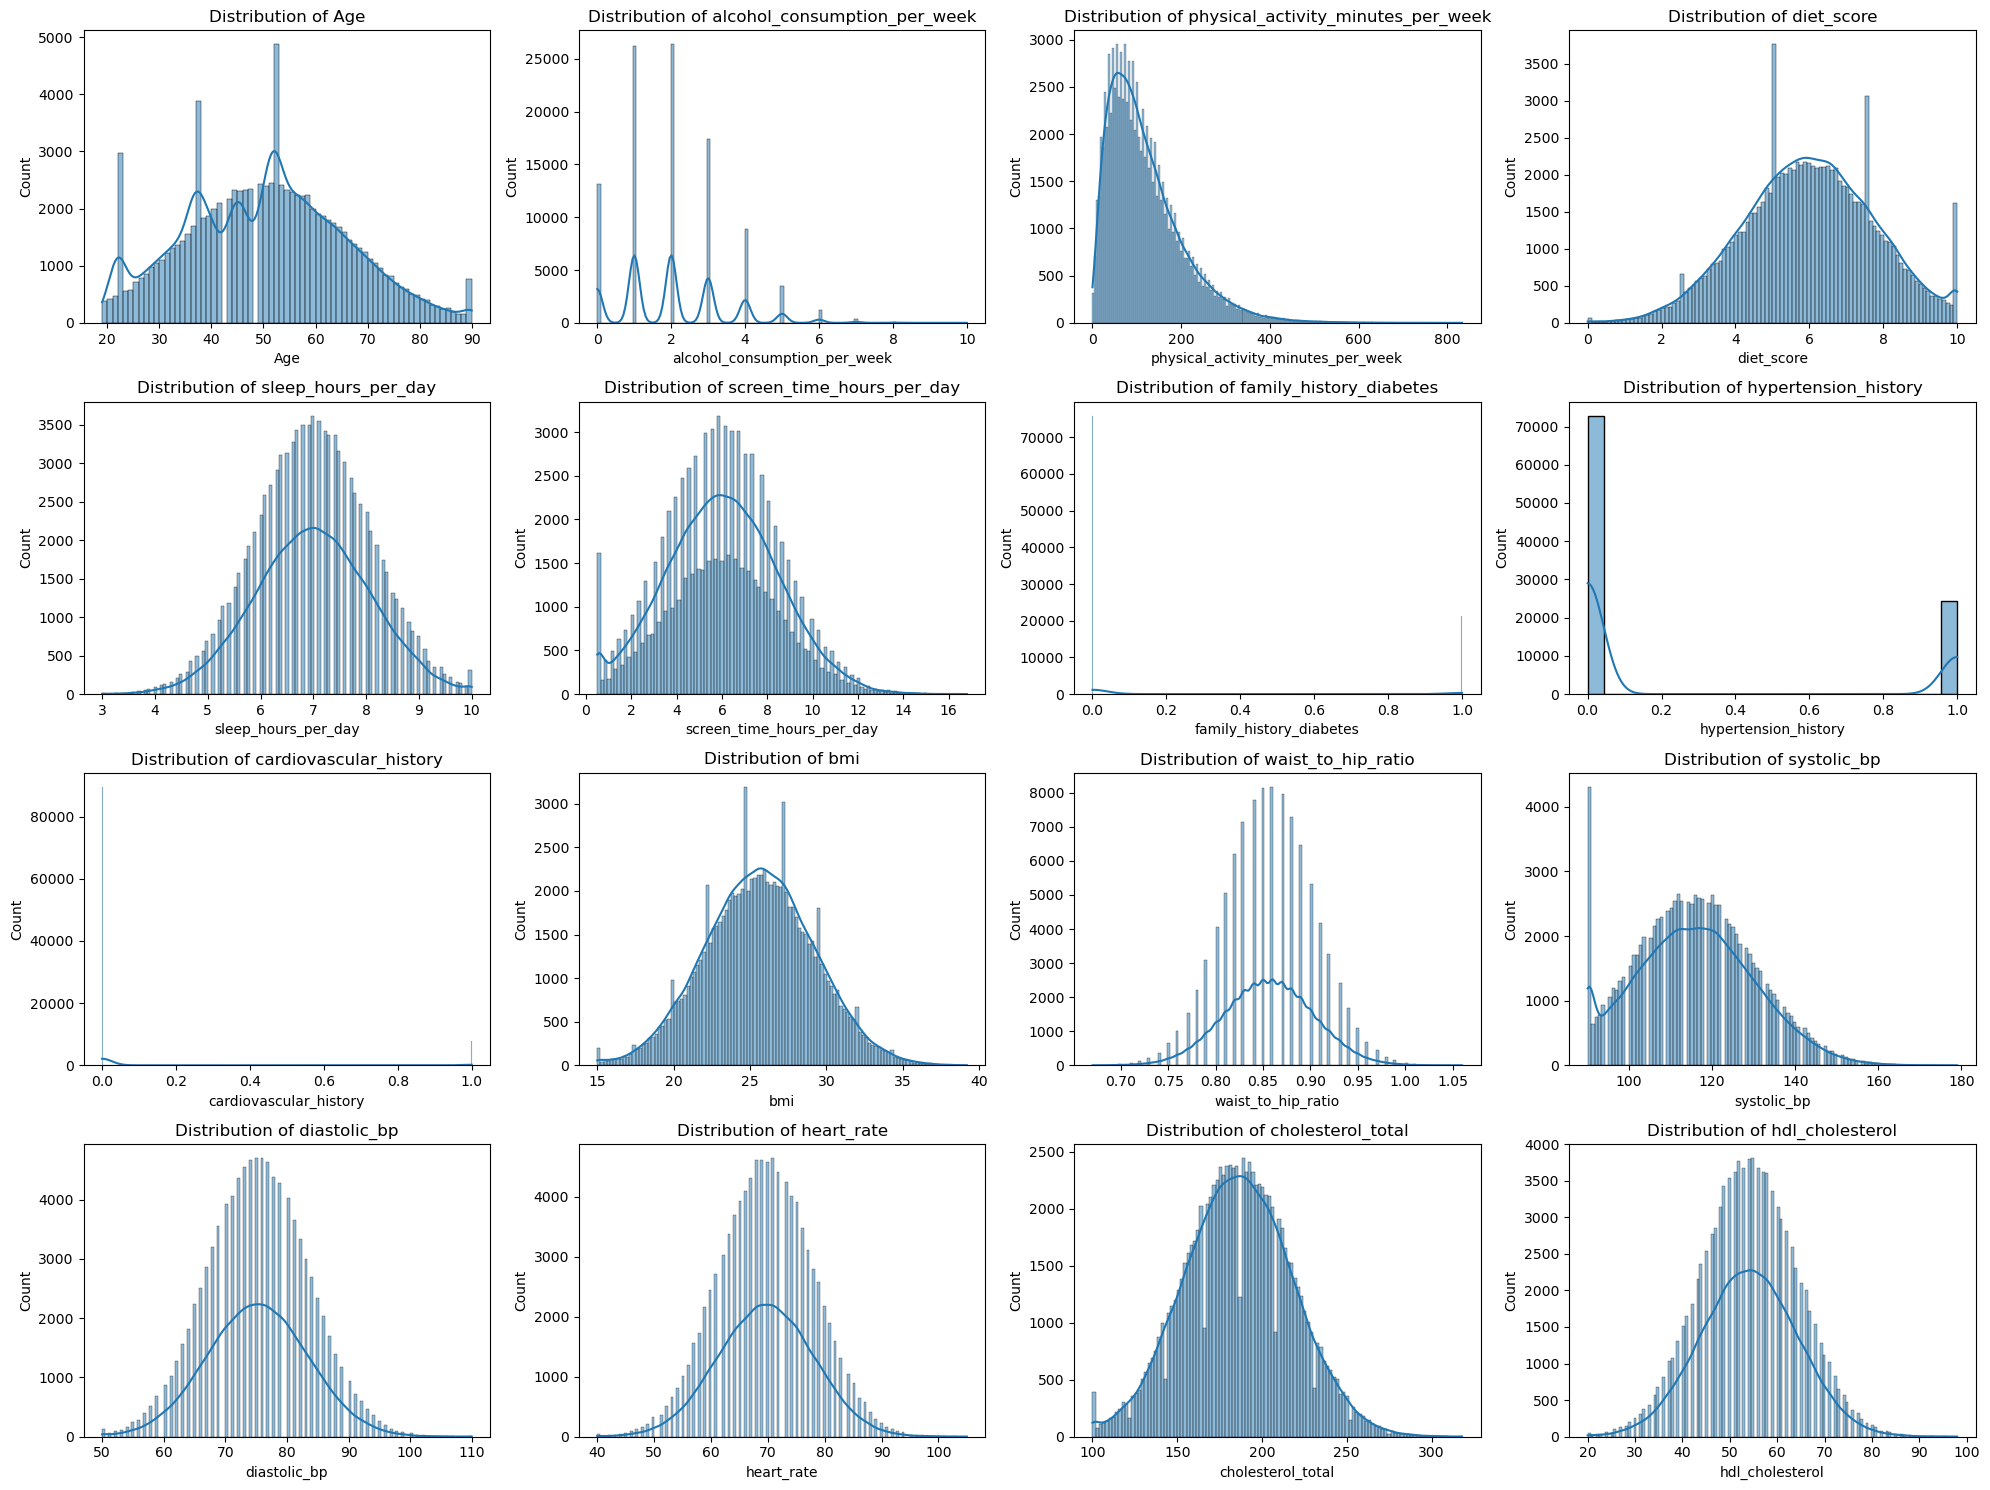

In [34]:
# Numerical features distribution
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(20,15))
for i, feature in enumerate(numerical_features[:16]):
    plt.subplot(4, 4, i+1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    plt.tight_layout()
plt.show()

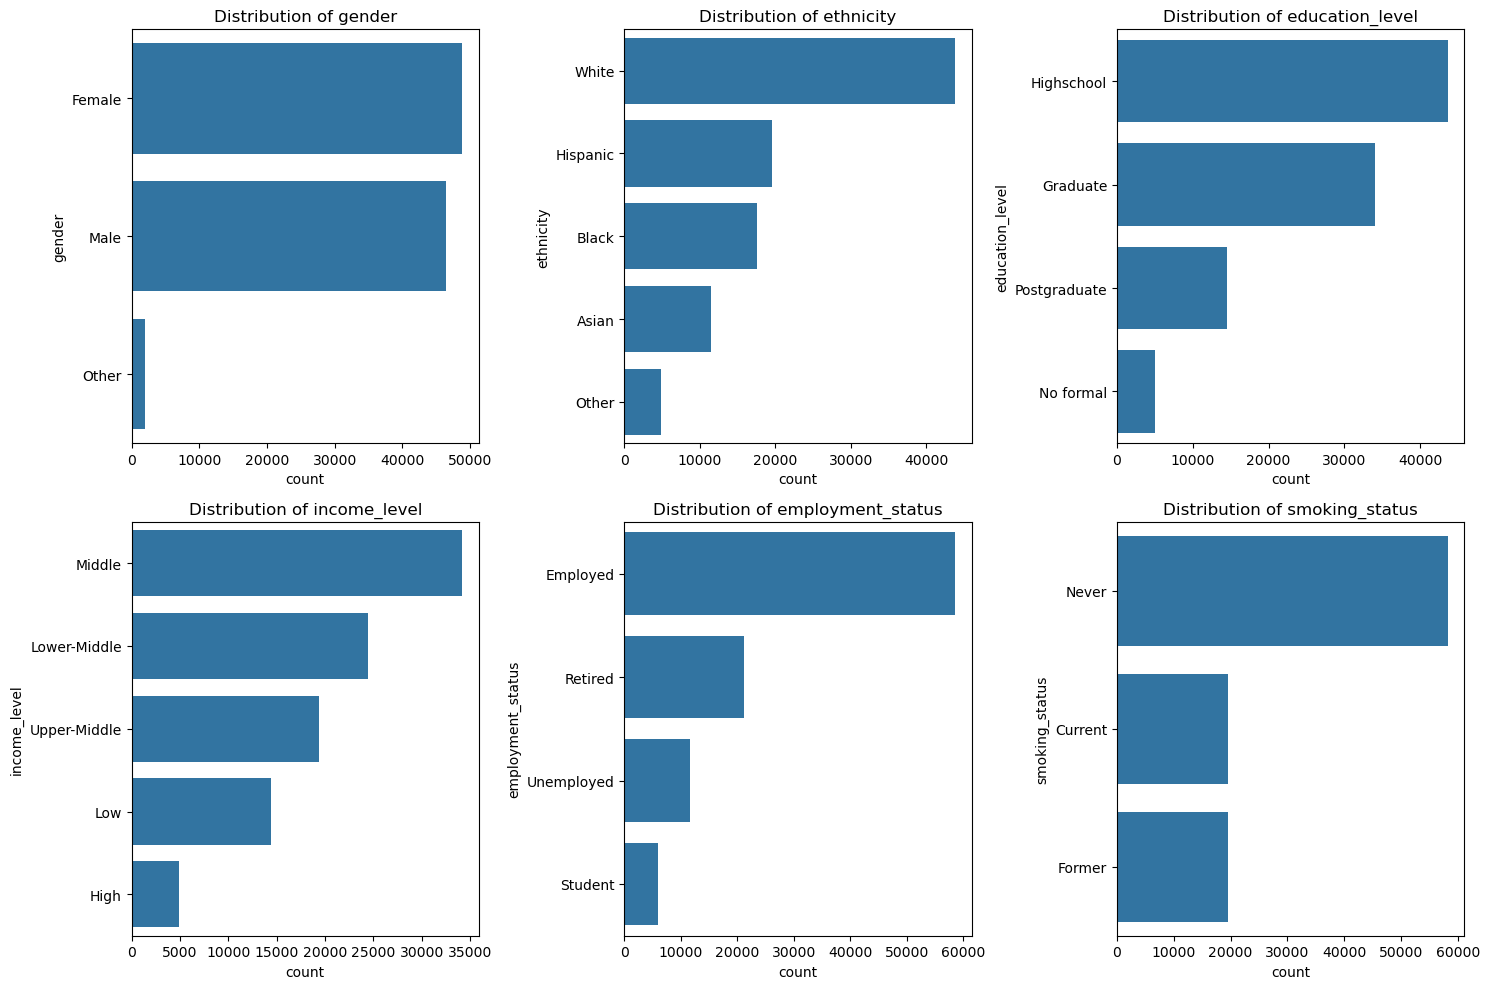

In [35]:
# Categorical features distribution
categorical_features = df.select_dtypes(include=['object']).columns
plt.figure(figsize=(15,10))
for i, feature in enumerate(categorical_features):
    if feature != 'diabetes_stage': #already plotted above
        plt.subplot(2, 3, i+1)
        sns.countplot(y=feature, data=df, order=df[feature].value_counts().index)
        plt.title(f'Distribution of {feature}')
        plt.tight_layout()
plt.show()

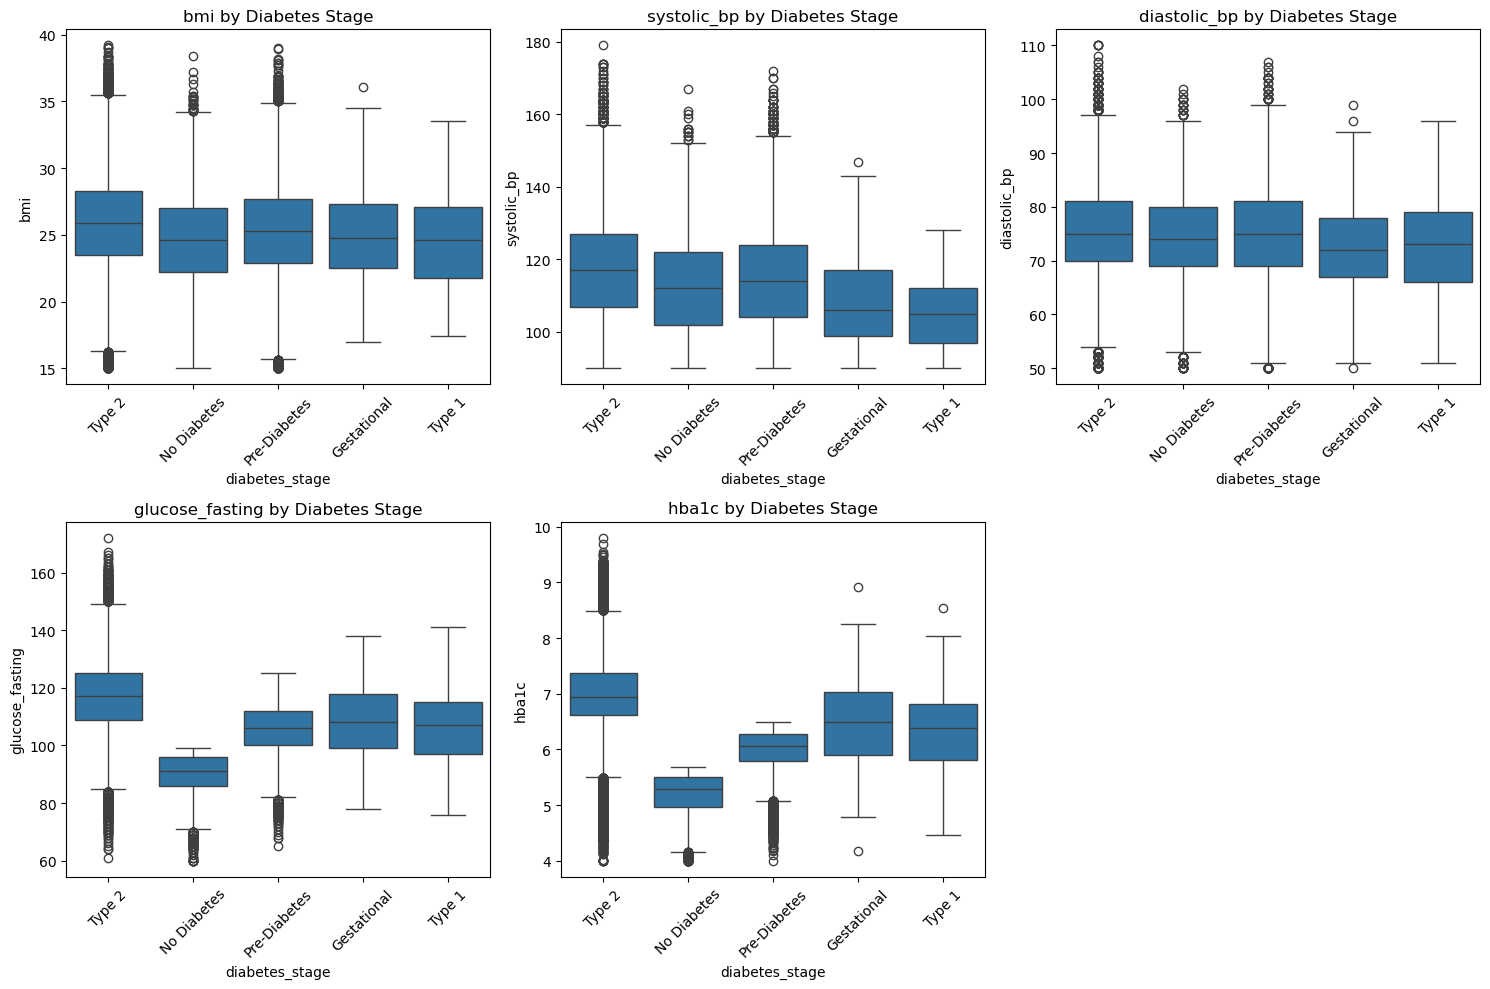

In [36]:
# Outlier detection using boxplots for key health metrics
health_metrics = ['bmi', 'systolic_bp', 'diastolic_bp', 'glucose_fasting', 'hba1c']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(health_metrics):
    plt.subplot(2,3,i+1)
    sns.boxplot(x='diabetes_stage', y=feature, data=df)
    plt.title(f'{feature} by Diabetes Stage')
    plt.xticks(rotation=45)
    plt.tight_layout()
plt.show()

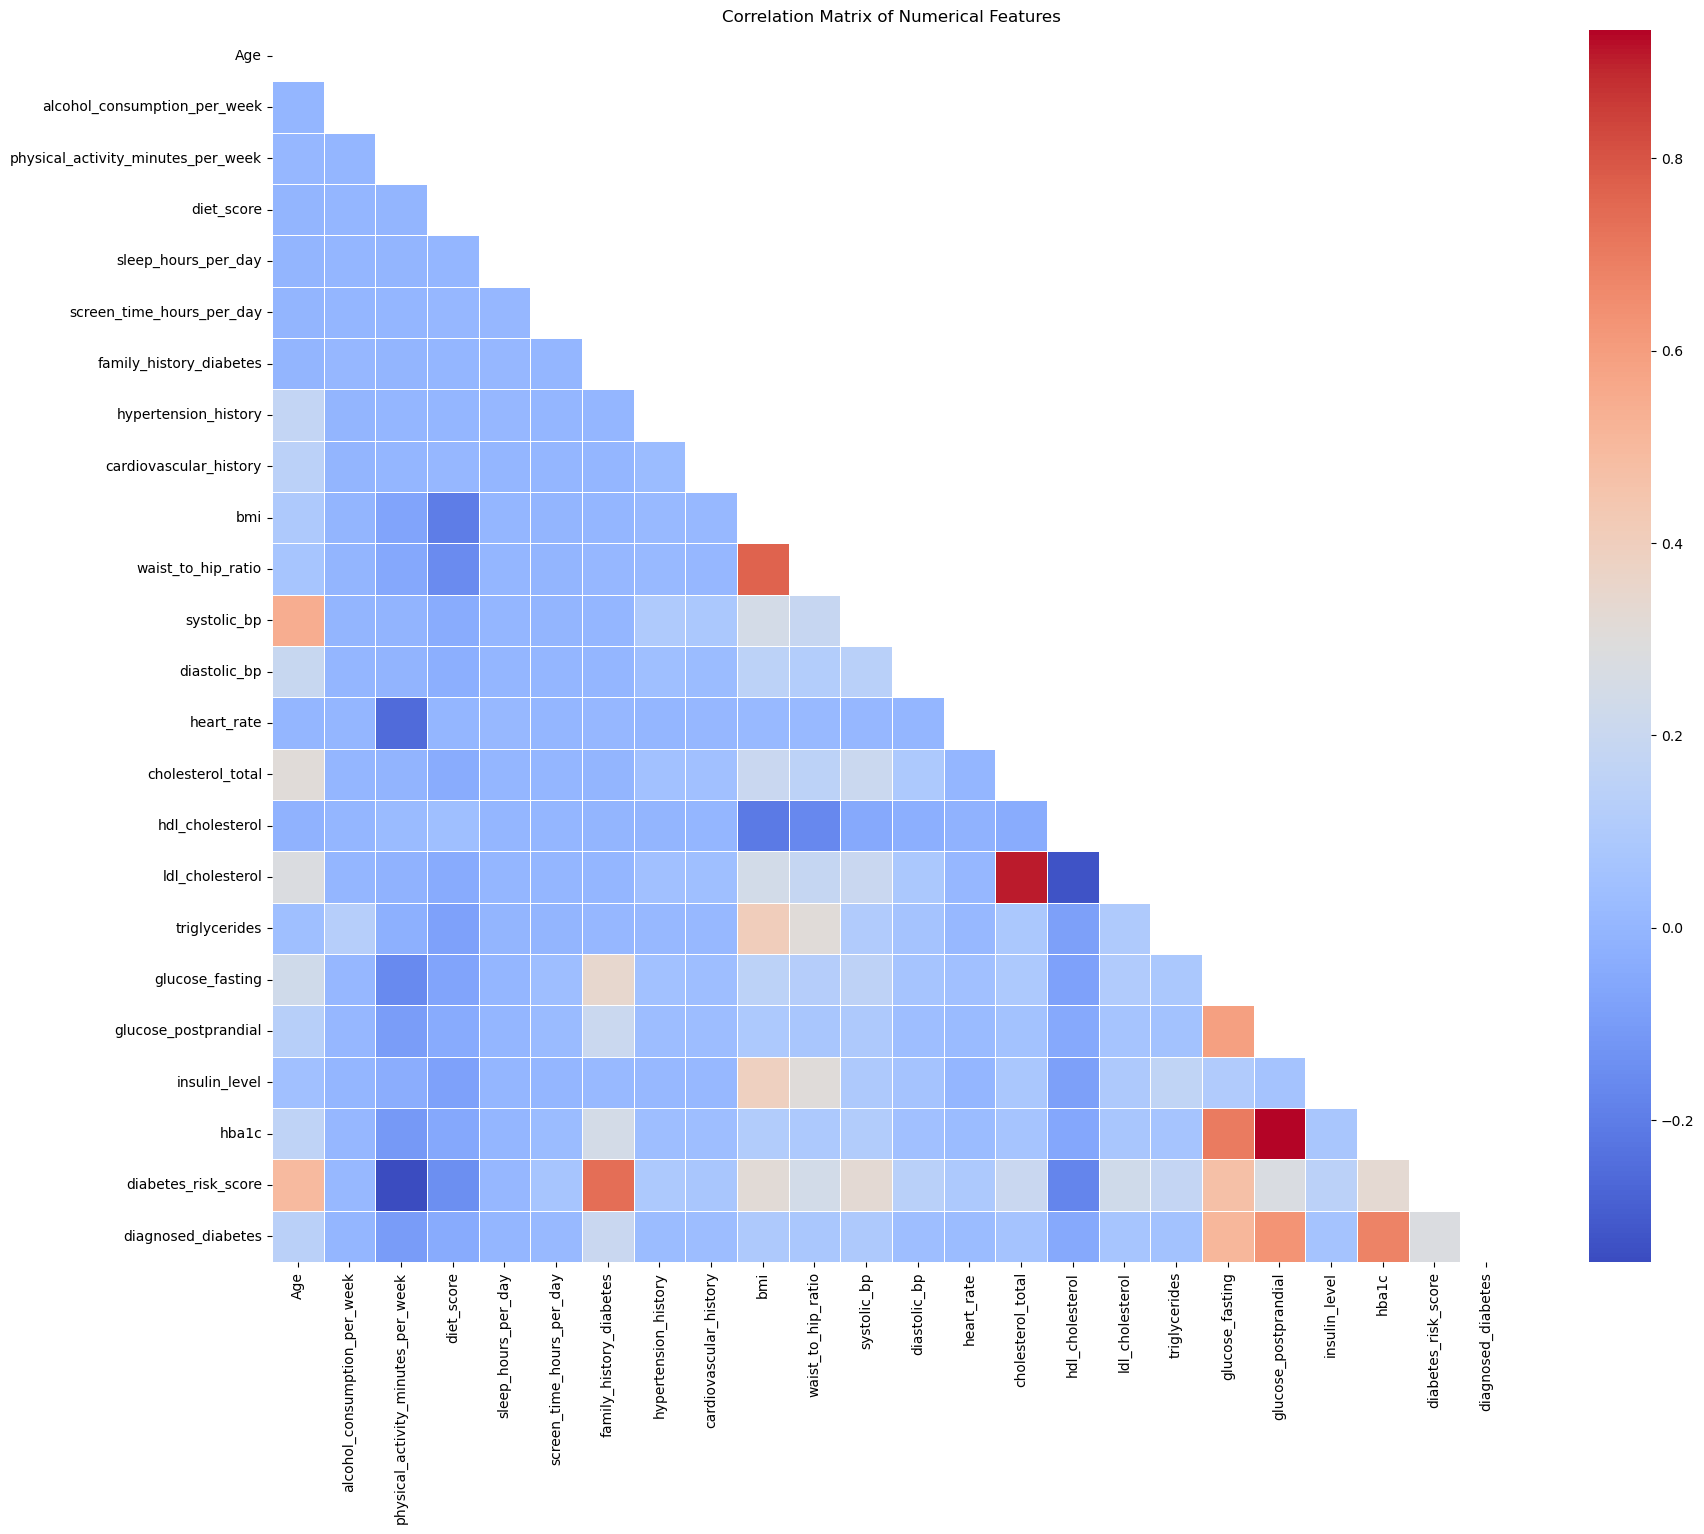

In [37]:
# Correlation analysis
plt.figure(figsize=(20,16))
correlation_matrix = df.select_dtypes(include=['int64', 'float64']).corr()
mask = np.triu(correlation_matrix)
sns.heatmap(correlation_matrix, annot=False, mask=mask, cmap='coolwarm', linewidth=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [38]:
# Top correlations with diabetes_risk_score
if 'diabetes_risk_score' in df.columns:
    correlations = correlation_matrix['diabetes_risk_score'].sort_values(ascending=False)
    print("\nTop Correlations with diabetes_risk_score:")
    display(correlations.drop('diabetes_risk_score'))


Top Correlations with diabetes_risk_score:


family_history_diabetes               0.733182
Age                                   0.494831
glucose_fasting                       0.470278
hba1c                                 0.330464
systolic_bp                           0.323446
bmi                                   0.314368
diagnosed_diabetes                    0.278343
glucose_postprandial                  0.277470
waist_to_hip_ratio                    0.242037
ldl_cholesterol                       0.228091
cholesterol_total                     0.198333
triglycerides                         0.181422
insulin_level                         0.142905
diastolic_bp                          0.135540
heart_rate                            0.091734
hypertension_history                  0.091030
cardiovascular_history                0.073549
screen_time_hours_per_day             0.070170
alcohol_consumption_per_week          0.010793
sleep_hours_per_day                   0.003162
diet_score                           -0.144465
hdl_cholester

<Figure size 1500x1000 with 0 Axes>

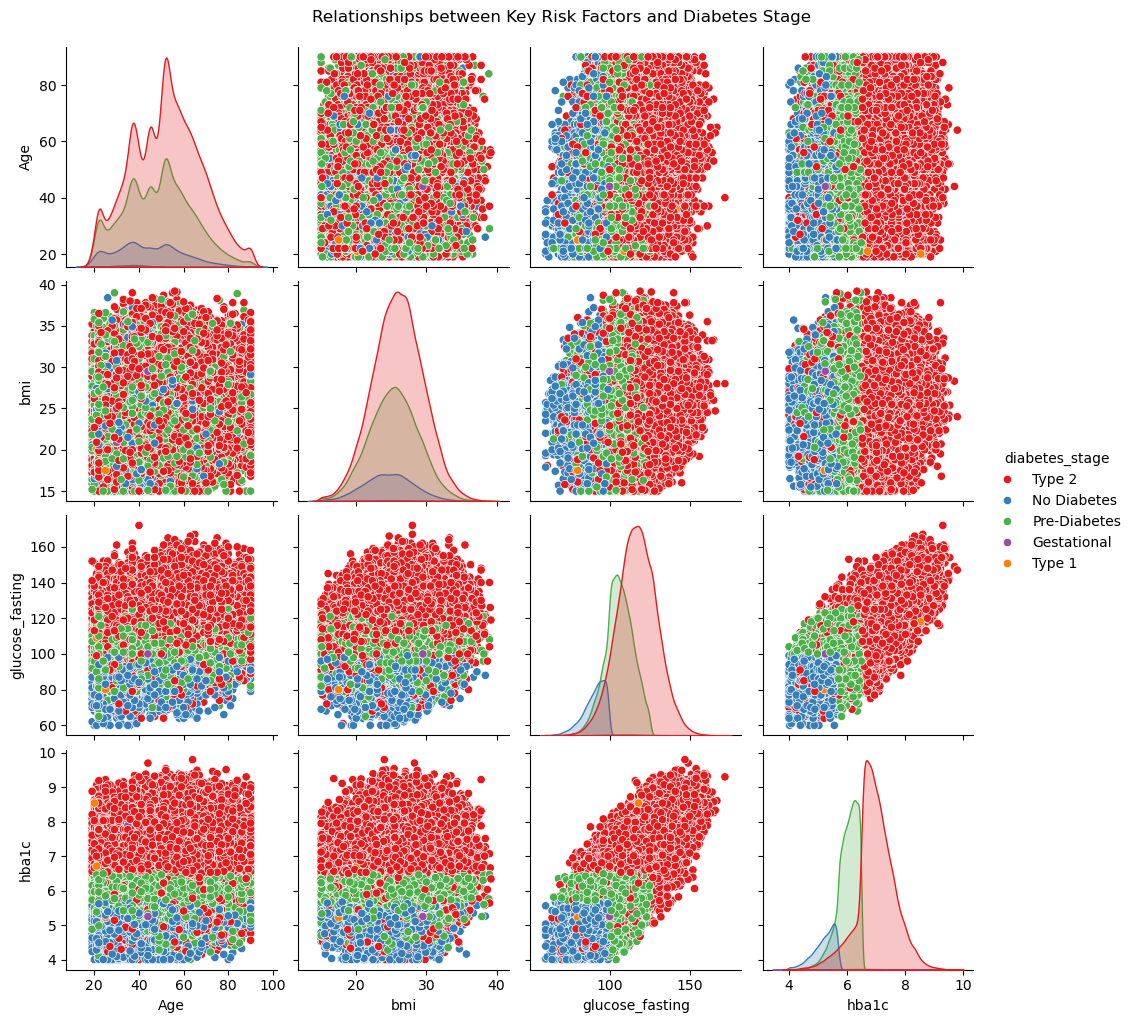

In [39]:
# Relationships between key risk factors and diabetes stage
plt.figure(figsize=(15,10))
sns.pairplot(df, vars=['Age', 'bmi', 'glucose_fasting', 'hba1c'], 
             hue='diabetes_stage', palette='Set1')
plt.suptitle('Relationships between Key Risk Factors and Diabetes Stage', y=1.02)
plt.show()